# ⚡ Simulación de Procesamiento Distribuido con RDD en PySpark

El procesamiento de grandes volúmenes de datos puede superar la capacidad de una sola máquina, tanto en memoria como en tiempo de cómputo. Para resolver este problema, se recurre al **procesamiento distribuido**, que consiste en dividir los datos y las tareas entre varios nodos o procesos que trabajan en paralelo.

**Spark** es una plataforma que facilita este tipo de procesamiento. Utiliza una estructura llamada **RDD** (Resilient Distributed Dataset), que permite dividir automáticamente los datos en **particiones**. Cada partición puede ser procesada de forma independiente y en paralelo, aprovechando los recursos de múltiples núcleos o máquinas.

Las **particiones** son fundamentales porque:
- Permiten el procesamiento paralelo, acelerando las operaciones sobre grandes conjuntos de datos.
- Mejoran la escalabilidad y el aprovechamiento de los recursos disponibles.
- Facilitan la tolerancia a fallos, ya que Spark puede reconstruir particiones perdidas a partir de los datos originales o de transformaciones previas.

En este notebook, simulamos este enfoque creando un RDD a partir de una lista de números y dividiéndolo en varias particiones. Así, podemos observar cómo Spark distribuye el trabajo y cómo se pueden medir y optimizar aspectos del procesamiento distribuido.

## 1️⃣ Configuración del entorno

In [2]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
from pyspark.sql import SparkSession

# Crear la SparkSession
spark = SparkSession.builder.appName("SimulacionDistribuida").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/06/24 11:28:58 WARN Utils: Your hostname, amidala, resolves to a loopback address: 127.0.1.1; using 192.168.1.47 instead (on interface wlp5s0)
25/06/24 11:28:58 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/24 11:28:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/06/24 11:29:00 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/06/24 11:29:00 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/06/24 11:29:00 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
25/06/24 11:29:00 WARN Utils: Serv

## 2️⃣ Crear un RDD con varias particiones

Aquí se crea un RDD a partir de una lista de números y se divide en 4 particiones para simular el procesamiento paralelo. Se realizan operaciones básicas como suma y máximo para observar la paralelización.

In [ ]:
# Crear una lista de números
numeros = list(range(1, 10001))

# Crear un RDD con 4 particiones
# `parallelize` se utiliza para crear crear RDD y definir particiones iniciales
rdd_numeros = spark.sparkContext.parallelize(numeros, 4)

# Verificar la cantidad de particiones
print("Particiones:", rdd_numeros.getNumPartitions())

Particiones: 4


## 3️⃣ Operaciones distribuidas sobre el RDD

In [17]:
# Calcular la suma de todos los elementos
print("Suma:", rdd_numeros.sum())

# Calcular el valor máximo
print("Máximo:", rdd_numeros.max())

Suma: 50005000
Máximo: 10000


In [ ]:
# Contar elementos por partición
# Nota: Spark llama automáticamente a esta función para cada partición,
# pasando el índice de la partición y un iterador con sus elementos.
# No es necesario (ni posible) pasarle argumentos manualmente.
def contar_elementos_por_particion(index, iterator):
    yield (index, sum(1 for _ in iterator))

conteo = rdd_numeros.mapPartitionsWithIndex(contar_elementos_por_particion).collect()
print("Elementos por partición:", conteo)

Elementos por partición: [(0, 2048), (1, 3072), (2, 2048), (3, 2832)]


> **Nota:**  
> La cantidad de elementos en cada partición puede variar. Esto ocurre porque Spark intenta distribuir los datos lo más equitativamente posible, pero la división exacta depende del número total de elementos y particiones, y del método utilizado para particionar.  
> En algunos casos, como se observa aquí, algunas particiones pueden tener significativamente más elementos que otras. Esto puede afectar el balance de carga y el rendimiento en un entorno distribuido real.

In [19]:
# Ver el contenido de cada partición
def mostrar_por_particion(index, iterator):
    yield (index, list(iterator))

particiones = rdd_numeros.mapPartitionsWithIndex(mostrar_por_particion).collect()
for idx, datos in particiones:
    print(f"Partición {idx}: {datos[:5]} ... ({len(datos)} elementos)")

Partición 0: [1, 2, 3, 4, 5] ... (2048 elementos)
Partición 1: [2049, 2050, 2051, 2052, 2053] ... (3072 elementos)
Partición 2: [5121, 5122, 5123, 5124, 5125] ... (2048 elementos)
Partición 3: [7169, 7170, 7171, 7172, 7173] ... (2832 elementos)


In [20]:
# Medir el tiempo de ejecución de una operación
import time

inicio = time.time()
resultado = rdd_numeros.sum()
fin = time.time()
print("Suma:", resultado)
print("Tiempo de ejecución:", fin - inicio, "segundos")

Suma: 50005000
Tiempo de ejecución: 0.5418686866760254 segundos


In [21]:
# Uso de cache para mejorar el rendimiento

# Cachear el RDD
rdd_numeros.cache()

# Primera ejecución (carga y cachea)
inicio = time.time()
_ = rdd_numeros.max()
fin = time.time()
print("Primera ejecución (cacheando):", fin - inicio, "segundos")

# Segunda ejecución (ya en caché)
inicio = time.time()
_ = rdd_numeros.max()
fin = time.time()
print("Segunda ejecución (desde caché):", fin - inicio, "segundos")

Primera ejecución (cacheando): 0.5230693817138672 segundos
Segunda ejecución (desde caché): 0.4279208183288574 segundos


In [22]:
# Cambiar el número de particiones y comparar
# `repartition` se usa para cambiar el número de particiones de un RDD existente
rdd_reparticionado = rdd_numeros.repartition(8)
print("Nuevo número de particiones:", rdd_reparticionado.getNumPartitions())

conteo_nuevo = rdd_reparticionado.mapPartitionsWithIndex(contar_elementos_por_particion).collect()
print("Elementos por partición tras reparticionar:", conteo_nuevo)

Nuevo número de particiones: 8


Elementos por partición tras reparticionar: [(0, 1250), (1, 1242), (2, 1260), (3, 1260), (4, 1258), (5, 1242), (6, 1248), (7, 1240)]


## 3️⃣ Entrenamiento distribuido de un modelo simple

A continuación se muestra cómo entrenar un modelo de regresión lineal usando PySpark. Aunque el dataset es pequeño, el entrenamiento se realiza de forma distribuida, aprovechando el motor de Spark.  
Esto permite escalar fácilmente a conjuntos de datos mucho más grandes y aprovechar la paralelización y la gestión de particiones que ofrece Spark.

> **Tip:** Se puede abrir [http://localhost:4040](http://localhost:4040) mientras se ejecuta el notebook para ver cómo Spark distribuye las tareas y las particiones entre los recursos disponibles.

In [43]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.linalg import Vectors
from pyspark.sql import Row
import random

# Crear un DataFrame sintético de ejemplo (y=2*x+1 con algo de ruido)
datos = [Row(label=2*x + 1 + random.uniform(-10, 10), features=Vectors.dense([x])) for x in range(0, 100)]
df = spark.createDataFrame(datos)
print("Número de particiones del DataFrame:", df.rdd.getNumPartitions())
df.show(5)

Número de particiones del DataFrame: 4
+-------------------+--------+
|              label|features|
+-------------------+--------+
| -4.080291503027712|   [0.0]|
|   2.67338829562571|   [1.0]|
| 0.9673012345956655|   [2.0]|
|-1.3369568265271088|   [3.0]|
|  2.386505211484474|   [4.0]|
+-------------------+--------+
only showing top 5 rows


> **Nota:**  
> Cuando se crea un DataFrame en Spark, los datos se dividen automáticamente en particiones para permitir el procesamiento distribuido.  
> Se puede consultar y modificar el número de particiones usando `df.rdd.getNumPartitions()` y `df.repartition(n)`.

In [44]:
# Crear el modelo de regresión lineal
lr = LinearRegression(featuresCol="features", labelCol="label")

# Entrenar el modelo (esto se distribuye automáticamente en Spark)
modelo = lr.fit(df)

# Mostrar los coeficientes aprendidos
print("Pendiente:", modelo.coefficients)
print("Ordenada al origen:", modelo.intercept)

25/06/24 12:26:49 WARN Instrumentation: [df5417a1] regParam is zero, which might cause numerical instability and overfitting.


Pendiente: [2.040532517593592]
Ordenada al origen: -1.6999715512558276


El modelo de regresión lineal entrenado aprende la relación entre x (features) y label (que es aproximadamente label = 2*x + 1).
Una vez entrenado, lo usamos para predecir el valor para nuevos valores de x.

In [ ]:
# Probar el modelo: predecir para nuevos valores de x

# Crear un DataFrame con nuevos valores de x
nuevos_x = [Row(features=Vectors.dense([v])) for v in [10.5, 25.7, 80.1, 102]]
df_nuevos = spark.createDataFrame(nuevos_x)

# Usar el modelo para predecir
predicciones = modelo.transform(df_nuevos)
predicciones.select("features", "prediction").show()

+--------+------------------+
|features|        prediction|
+--------+------------------+
|  [10.5]| 19.72561988347689|
|  [25.7]| 50.74171415089949|
|  [80.1]| 161.7466831079909|
| [102.0]|206.43434524329058|
+--------+------------------+



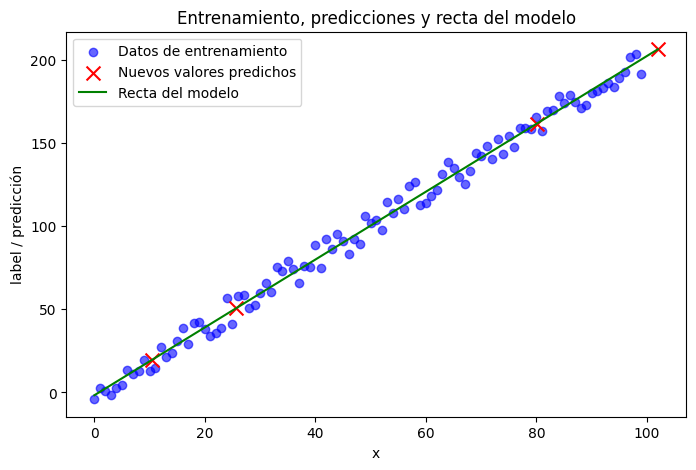

In [ ]:
# Graficar los puntos de entrenamiento, los nuevos valores predichos y la recta del modelo

import matplotlib.pyplot as plt
import numpy as np

# Obtener los datos de entrenamiento
x_entrenamiento = [row.features[0] for row in df.collect()]
y_entrenamiento = [row.label for row in df.collect()]

# Obtener los nuevos valores y sus predicciones
nuevos_x_valores = [10.5, 25.7, 80.1, 102]
y_predichos = predicciones.select("prediction").rdd.flatMap(lambda x: x).collect()

# Calcular la recta del modelo para el rango de x
x_linea = np.linspace(min(x_entrenamiento + nuevos_x_valores), max(x_entrenamiento + nuevos_x_valores), 100)
y_linea = modelo.coefficients[0] * x_linea + modelo.intercept

plt.figure(figsize=(8,5))
plt.scatter(x_entrenamiento, y_entrenamiento, label="Datos de entrenamiento", color="blue", alpha=0.6)
plt.scatter(nuevos_x_valores, y_predichos, label="Nuevos valores predichos", color="red", marker="x", s=100)
plt.plot(x_linea, y_linea, label="Recta del modelo", color="green")
plt.xlabel("x")
plt.ylabel("label / predicción")
plt.title("Entrenamiento, predicciones y recta del modelo")
plt.legend()
plt.show()

## Cierre de la sesión Spark

In [ ]:
spark.stop()